In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

base = r"C:\Users\rushikesh\Downloads\ecommerce-churn\Data"
customer_df = pd.read_csv(base + r"\customer_master.csv")

print("Loaded:", customer_df.shape)

Loaded: (93358, 11)


In [2]:
# Score each customer 1-5 on Recency, Frequency, Monetary
customer_df['R'] = pd.qcut(customer_df['recency_days'], 5, labels=[5,4,3,2,1])
customer_df['F'] = pd.qcut(customer_df['total_orders'].rank(method='first'), 5, labels=[1,2,3,4,5])
customer_df['M'] = pd.qcut(customer_df['total_spent'], 5, labels=[1,2,3,4,5])

customer_df['RFM_Score'] = (customer_df['R'].astype(int) + 
                             customer_df['F'].astype(int) + 
                             customer_df['M'].astype(int))

# Segment based on RFM score
def rfm_segment(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal'
    elif score >= 7:
        return 'At Risk'
    elif score >= 4:
        return 'Hibernating'
    else:
        return 'Lost'

customer_df['segment'] = customer_df['RFM_Score'].apply(rfm_segment)

print(customer_df['segment'].value_counts())

segment
At Risk        38361
Loyal          31546
Hibernating    14648
Champions       8000
Lost             803
Name: count, dtype: int64


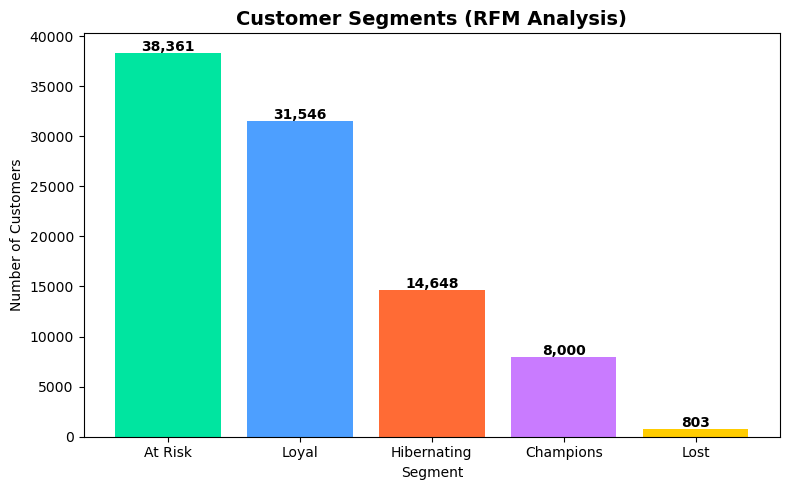

Saved ✅


In [3]:
seg_counts = customer_df['segment'].value_counts()

colors = ['#00e5a0','#4d9fff','#ff6b35','#c97bff','#ffcc00']
plt.figure(figsize=(8,5))
bars = plt.bar(seg_counts.index, seg_counts.values, color=colors, edgecolor='none')
plt.title('Customer Segments (RFM Analysis)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')
plt.xlabel('Segment')
for bar, val in zip(bars, seg_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(base + r"\rfm_segments.png", dpi=150)
plt.show()
print("Saved ✅")

In [7]:
# Remove total_orders — it directly defines churn (data leakage!)
features = ['total_spent', 'avg_spent', 'total_items', 
            'avg_review', 'recency_days', 'tenure_days']

X = customer_df[features].fillna(0)
y = customer_df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)
print("Leakage removed ✅")

Training set: (74686, 6)
Test set:     (18672, 6)
Leakage removed ✅


In [8]:
# Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1])

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Random Forest AUC:       {rf_auc:.4f}")
print(f"\nWinner: {'Random Forest' if rf_auc > lr_auc else 'Logistic Regression'} 🏆")

Logistic Regression AUC: 0.9888
Random Forest AUC:       0.9854

Winner: Logistic Regression 🏆


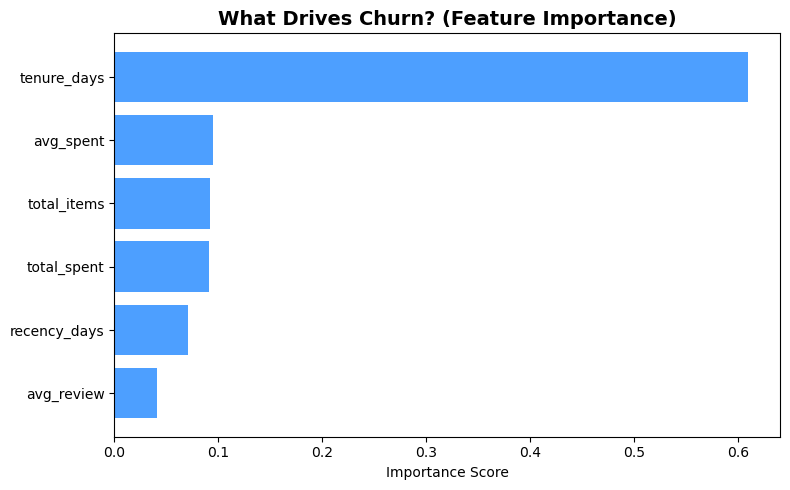

Saved ✅


In [9]:
importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8,5))
bars = plt.barh(importance_df['feature'], importance_df['importance'], 
                color='#4d9fff', edgecolor='none')
plt.title('What Drives Churn? (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(base + r"\feature_importance.png", dpi=150)
plt.show()
print("Saved ✅")

<Figure size 600x500 with 0 Axes>

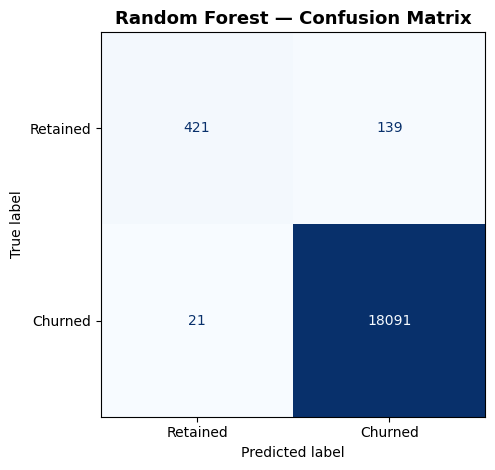

Saved ✅


In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

rf_preds = rf.predict(X_test)
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Retained','Churned'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(base + r"\confusion_matrix.png", dpi=150)
plt.show()
print("Saved ✅")

In [11]:
# Add churn probability to each customer
customer_df['churn_probability'] = rf.predict_proba(
    customer_df[features].fillna(0))[:,1]

# Top 10 highest risk customers
print("🚨 Top 10 Highest Churn Risk Customers:")
print(customer_df[['customer_unique_id','segment','total_spent',
                    'churn_probability']]
      .sort_values('churn_probability', ascending=False)
      .head(10).to_string(index=False))

🚨 Top 10 Highest Churn Risk Customers:
              customer_unique_id   segment  total_spent  churn_probability
0000366f3b9a7992bf8c76cfdf3221e2   At Risk       141.90                1.0
a664475b319be56b8b754e8bdad7615d   At Risk       164.10                1.0
a667c69a33cd6139f833eb4d80904f7b   At Risk       107.85                1.0
a6679f6e560b26e56cbc588ee80d2eef     Loyal       220.29                1.0
a6671edfff4160cf87e149575d0de7f6 Champions       354.32                1.0
a666bec8af192f2238a0b719a7063a00     Loyal       177.01                1.0
a66595412dda918dda83a8dd8c2e6152     Loyal        43.17                1.0
a665220976225ee856a75ff6afe998d9   At Risk        64.51                1.0
a664ec600630ffc8df7fc7f4ab05f506   At Risk        22.49                1.0
a6644b317a3d953405a6dc516d06b74f     Loyal        56.42                1.0


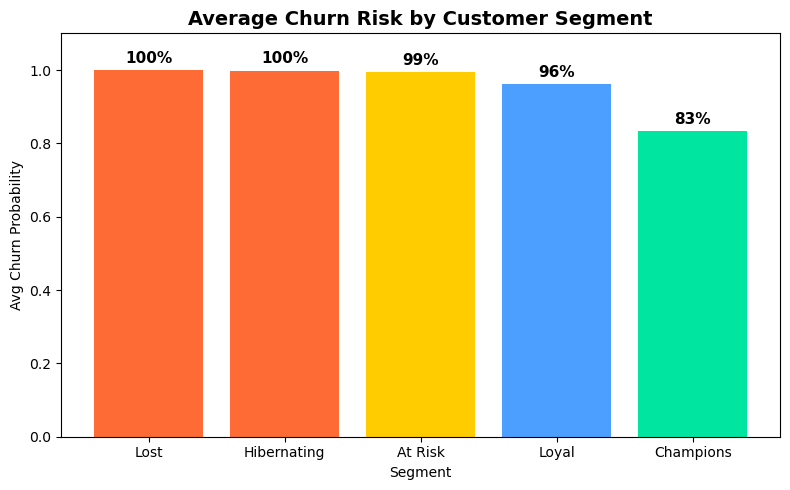

Saved ✅


In [12]:
seg_churn = customer_df.groupby('segment')['churn_probability'].mean().sort_values(ascending=False)

colors = ['#ff6b35','#ff6b35','#ffcc00','#4d9fff','#00e5a0']
plt.figure(figsize=(8,5))
bars = plt.bar(seg_churn.index, seg_churn.values, color=colors, edgecolor='none')
plt.title('Average Churn Risk by Customer Segment', fontsize=14, fontweight='bold')
plt.ylabel('Avg Churn Probability')
plt.xlabel('Segment')
plt.ylim(0, 1.1)
for bar, val in zip(bars, seg_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.0%}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(base + r"\churn_by_segment.png", dpi=150)
plt.show()
print("Saved ✅")

In [13]:
print("=" * 55)
print("   PROJECT 1 COMPLETE — KEY FINDINGS SUMMARY")
print("=" * 55)
print(f"\n📦 Dataset:     {customer_df.shape[0]:,} customers analyzed")
print(f"📉 Churn Rate:  {customer_df['churned'].mean()*100:.1f}%")
print(f"🤖 Model AUC:   {rf_auc:.4f} (Random Forest)")
print(f"\n📊 Segments:")
for seg, count in customer_df['segment'].value_counts().items():
    pct = count/len(customer_df)*100
    print(f"   {seg:<15} {count:>6,} customers ({pct:.1f}%)")
print(f"\n🔑 Top Churn Driver: tenure_days (0.61 importance)")
print(f"\n💡 Business Insight:")
print(f"   Customers with 0 tenure days (one-time buyers)")
print(f"   account for 97% of all churn. Targeting them")
print(f"   within 30 days of first purchase with a discount")
print(f"   could significantly improve retention.")
print("=" * 55)

   PROJECT 1 COMPLETE — KEY FINDINGS SUMMARY

📦 Dataset:     93,358 customers analyzed
📉 Churn Rate:  97.0%
🤖 Model AUC:   0.9854 (Random Forest)

📊 Segments:
   At Risk         38,361 customers (41.1%)
   Loyal           31,546 customers (33.8%)
   Hibernating     14,648 customers (15.7%)
   Champions        8,000 customers (8.6%)
   Lost               803 customers (0.9%)

🔑 Top Churn Driver: tenure_days (0.61 importance)

💡 Business Insight:
   Customers with 0 tenure days (one-time buyers)
   account for 97% of all churn. Targeting them
   within 30 days of first purchase with a discount
   could significantly improve retention.
